<a href="https://colab.research.google.com/github/kotatakehara/Self-efficacy/blob/draft/Unsuccessful_Kendama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# GoogleドライブをGoogle Colabにマウント
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files

Mounted at /content/drive


In [2]:
#pandasをインポート
import glob
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

original_pattern = '/content/drive/MyDrive/Unity_play_data/sub1/Kendama_no1.csv'

In [3]:
#テストコード
Kendama_file_path = glob.glob(original_pattern)
df=pd.read_csv(Kendama_file_path[0],engine='python')
df.head()

,ElapsedTime,AbsoluteTime,ball.Position.x,ball.Position.y,ball.Position.z,ball.Rotation.x,ball.Rotation.y,ball.Rotation.z,ball.Quaternion.x,ball.Quaternion.y,...,relativeAcceleration.z,GraspSide,SelfOrOther,playing,Blinkflag,RightEyeOpenness,LeftEyeOpenness,SuccessJudge,Ver22.11.10,Unnamed: 115
0,0.000000,11:17:42:348,0.7082,0.8366,-1.2994,270.7517,240.0344,138.9963,-0.7003,0.1133,...,-1.233879,Right,Self,False,False,0.1,0.563030,False,NaN,NaN
1,0.050679,11:17:42:371,0.7096,0.8373,-1.2993,270.6991,208.2707,170.7791,-0.7014,0.1156,...,-0.196978,Right,Self,False,False,0.1,0.522788,False,NaN,NaN
2,0.066505,11:17:42:385,0.7103,0.8374,-1.2992,270.7252,202.8740,176.1911,-0.7017,0.1161,...,-0.213589,Right,Self,False,False,0.1,0.530839,False,NaN,NaN
3,0.080885,11:17:42:401,0.7106,0.8375,-1.2991,270.7605,205.2770,173.7975,-0.7018,0.1159,...,1.002210,Right,Self,False,False,0.1,0.530839,False,NaN,NaN
4,0.103577,11:17:42:423,0.7112,0.8377,-1.2989,270.8589,220.3300,158.7662,-0.7018,0.1146,...,0.211456,Right,Self,False,False,0.1,0.520692,False,NaN,NaN


In [4]:
class Kendama_analyze():
  def __init__(self, original_pattern, number_people):
    self.original_pattern = original_pattern #ファイルのリンクを格納
    self.number_people = number_people #どれだけのデータ数を使用するかを決定する変数
    self.threshold = {
        'easy': 0.092,
        'normal': 0.07,
        'hard' : 0.048
    }#被験者一人の解析を行う関数

  def start_analyze(self, Kendama_file_path, pattern):
    succ_check = False
    difficult = "easy"
    trialCheck = False
    dataCheck = True #dataが正しいのかのチェックを行う。もし、おかしければ１つ前の施工データを使用するようにする
    Abs_degree_failure = np.array([])
    p = np.empty((0,2)) #皿のガウス分布の平均値を格納する配列
    dispersion = np.empty((0,2))     #被験者のやる気を表す分散を格納する配列
    x = np.array([])  #試行回数を格納

      #csvファイルの読み込み(この読み込みのところにおかしい部分がある)
    df=pd.read_csv(Kendama_file_path[0],engine='python') #CSVファイルのパスを指定
    i = 0
    #excelデータ無くなるまで回し続けるループを書く
    for index, row in df.iterrows(): #1行目から順番に内容を取得している処理
      #ループ終了のコード
      if row.isnull().all():  # 全てのカラムが NaN の場合、ループを停止
        break
      if len(p) == 0 and abs(row['sword.Velocity.x']) <= 0.01 and abs(row['sword.Velocity.y']) <= 0.01 and abs(row['sword.Velocity.z']) <= 0.01: #最初の平均値を格納
        p = np.append(p, [[row['ball.Position.x'],row['ball.Position.y']]], axis = 0)

      #試行を行なったかどうかの確認を行うプログラムを書く
      if trialCheck == False:
        if row['ball.Position.y'] >= row['sword.Position.y'] and row['ball.Velocity.y'] >= 0:
          trialCheck = True

      if trialCheck == True:
        #データが無事に取れたときに分岐する条件
        if -0.01 <= row['ball.Position.y'] - row['sword.Position.y'] <= 0.01 and row['ball.Velocity.y'] < 0:
          trialCheck = False
          dataCheck = True
          p = np.append(p, [[row['ball.Position.x'],row['ball.Position.y']]], axis = 0) #plateの原点を次回の平均値に入れる
          abs_degree_failure = abs(np.sqrt((row['ball.Position.x'] - row['sword.Position.x'])**2 + (row['ball.Position.z'] - row['sword.Position.z'])**2)) #皿の中心と落下位置の差（絶対値）
          variance_x = (row['sword.Position.x']-p[i][0])**2 #分散を求める一般的な公式である、データから平均を引いて２乗した値を分散にした（値は１つしか使わないので１で割る）←正確に行うなら、一定の差の高さの時の値を全て使うとおそらく良い
          variance_y = (row['sword.Position.y']-p[i][1])**2
          dispersion = np.append(dispersion, [[variance_x,variance_y]], axis=0)
          Abs_degree_failure = np.append(Abs_degree_failure, abs_degree_failure)
          x =np.append(x, (i+1))
          i += 1

        if row['ball.Velocity.y'] > 0 and row['ball.Position.y'] < row['sword.Position.y']:
          trialCheck = False
          dataCheck = False

      #持ち上がった後にけん玉が条件の範囲内に入らなかった場合の例外処理が必要（つまりdataCheckがFalseの時）
      if dataCheck == False:
        #dataがちゃんととれなかった時のコードを書き足す（2次元での分散への影響はないと考え一旦無視）
        dataCheck = True

      #最後に余分な要素を削除
    p = np.delete(p, 0, axis=0)
    return x,p,dispersion,Abs_degree_failure

  #ここまで確認OK
  #指定した幅での平均を使った解析 ※width=0の時の例外処理が必要そう
  #ばらつきの度合い（分散）を求めるプログラムを作る
  def divided_analyze(self, width, pattern):
    data = []
    #difficulty_levels = ['easy', 'normal', 'hard']
    for j in range(1, self.number_people+1):  # 1から10までの数字でループ
        # new_number = '{:02d}'.format(i)  # 2桁の数字にフォーマット
        new_pattern = self.original_pattern.replace('sub1/Kendama_no1', f'sub{j:1d}/Kendama_no{j:1d}')  # 数字部分を置換
        Kendama_file_path = glob.glob(new_pattern)
        # Kendama_file_path = sorted(Kendama_file_path) #ファイルの順番がおかしいので並び替えを行うコード

        x,p,dispersion,Abs_degree_failure = self.start_analyze(Kendama_file_path, pattern)

        #新しい配列に1つずつずらした5つの値の平均を入れる
        new_x = x[0:(len(x)-width+1)]
        new_p = np.array([np.mean(p[i:i+width, :], axis=0) for i in range(len(p)-width+1)])
        new_dispersion = np.array([np.mean(dispersion[i:i+width, :], axis=0) for i in range(len(dispersion)-width+1)])
        new_Abs_degree_failure = np.array([np.mean(Abs_degree_failure[i:i+width]) for i in range(len(Abs_degree_failure)-width+1)])

        data.append({
                'person': j,
                'x': new_x,
                'p': new_p,
                'dispersion': new_dispersion,
                'Abs_degree_failure': new_Abs_degree_failure
            })
    # 新しいDataFrameを作成
    df = pd.DataFrame(data)
    return df

  def loop_analyze(self, pattern):
    data = []
    #difficulty_levels = ['easy', 'normal', 'hard']
    for j in range(1, self.number_people+1):  # 1からnumber_peopleまでの数字でループ
        new_pattern = self.original_pattern.replace('sub1/Kendama_no1', f'sub{j:1d}/Kendama_no{j:1d}')  # 数字部分を置換
        Kendama_file_path = glob.glob(new_pattern)
        # Kendama_file_path = sorted(Kendama_file_path)  # ファイルの順番を並び替え

        x, p, dispersion, Abs_degree_failure = self.start_analyze(Kendama_file_path, pattern)

        data.append({
                'person': j,
                'x': x,
                'p': p,
                'dispersion': dispersion,
                'Abs_degree_failure': Abs_degree_failure
            })

    df = pd.DataFrame(data)
    return df



In [5]:
class Kendama_show(Kendama_analyze):
  def __init__(self, original_pattern, number_people):
    super().__init__(original_pattern, number_people)
    self.colors = {
    'abs': 'r',
    'dispersion': 'b'
    }

  def make_result(self, pattern, width=None):
    if pattern == "default":
      df_analyze = self.loop_analyze(pattern)
      return df_analyze
    else:
      df_divided = self.divided_analyze(width, pattern)
      return df_divided

  def show_result(self, df, column, width):
    # 各データのラベルと色の辞書
    data_dict = {
        "degree failure": {"data": df['Abs_degree_failure'], "color": 'r', "ylabel": 'degree failure', "ylim": (0, 0.3)},
        "σ_X^2,σ_Y^2": {"data": df['dispersion'].apply(lambda x: abs(x[:, 0] + x[:, 1])), "color": 'green', "ylabel": 'σ_X^2,σ_Y^2', "ylim": (0, 0.08)},
        "σ_X^2": {"data": df['dispersion'].apply(lambda x: x[:, 0]), "color": 'b', "ylabel": 'σ_X^2', "ylim": (0, 0.05)},
        "σ_Y^2": {"data": df['dispersion'].apply(lambda x: x[:, 1]), "color": 'b', "ylabel": 'σ_Y^2', "ylim": (0, 0.05)}

    }

    fig, axs = plt.subplots(column, self.number_people, figsize=(50, column*3+1))

    for i in range(self.number_people):
      df_filtered = df[(df['person'] == i+1)]
      for j, (label, props) in enumerate(data_dict.items()):
        if j >= column:
          break
        axs[j, i].plot(df_filtered['x'].values[0], props["data"][df_filtered.index].values[0], linewidth=4, color=props["color"], marker="o")
        axs[j, i].set_ylabel(props["ylabel"])
        axs[j, i].set_ylim(props["ylim"])
        axs[j, i].set_title(f"sub{i+1}", fontsize = 18)
        axs[j, i].set_xticks(list(range(0, len(df_filtered['x'].values[0]), 50)))

        # if division == 5:
        #   axs[j, i].set_xticks(np.arange(1, 5*division+1, division))  # [1, 2, 3, 4] if division=5
        # else:
        #   axs[j, i].set_xticks(np.arange(5, max(A_x_L[i])+1, 5*division))  # [5, 10, 15, 20] if division=1

        axs[j, i].set_xlabel("t (times)", fontsize = 18)

    plt.tight_layout()
    #plt.savefig(f"data_fitting_ajustment.png")
    #files.download(f'data_fitting_ajustment.png')
    plt.show()


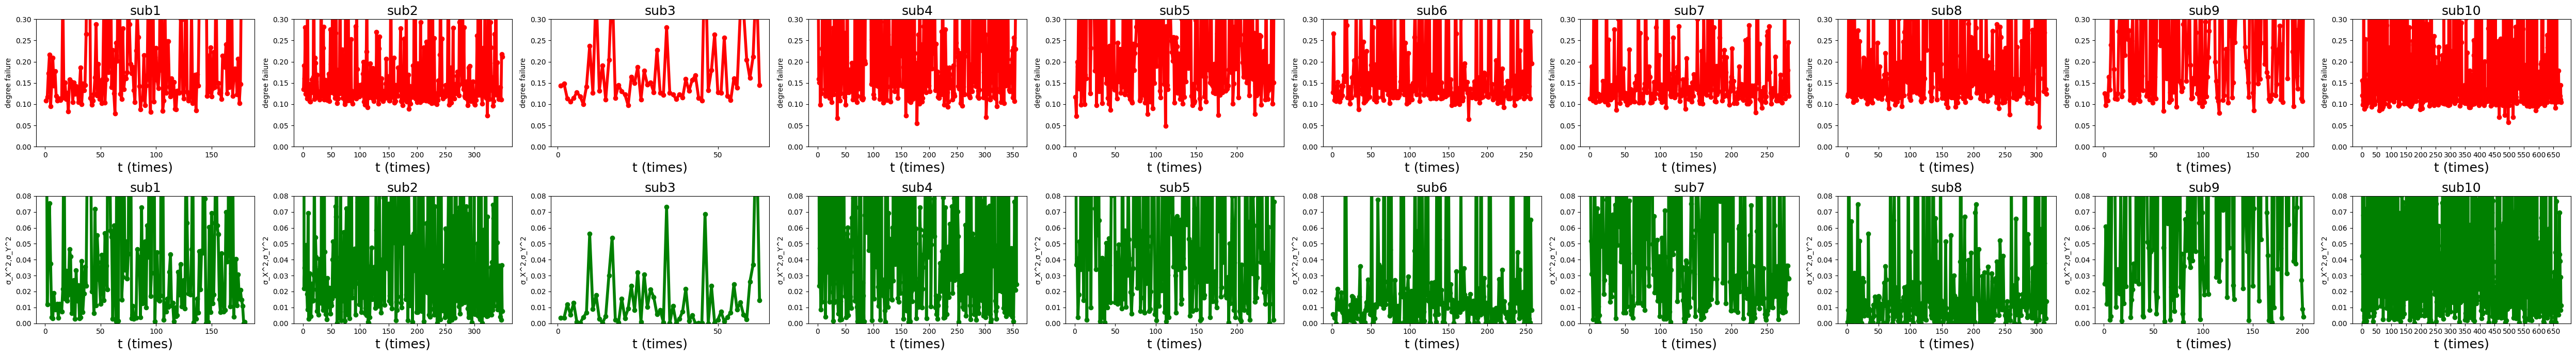

In [6]:
original_pattern = '/content/drive/MyDrive/Unity_play_data/sub1/Kendama_no1.csv'
number_people = 10
inamura_data_show = Kendama_show(original_pattern, number_people)
width = 0
df_analyze = inamura_data_show.make_result("default")
column = 2
inamura_data_show.show_result(df_analyze, column, width)

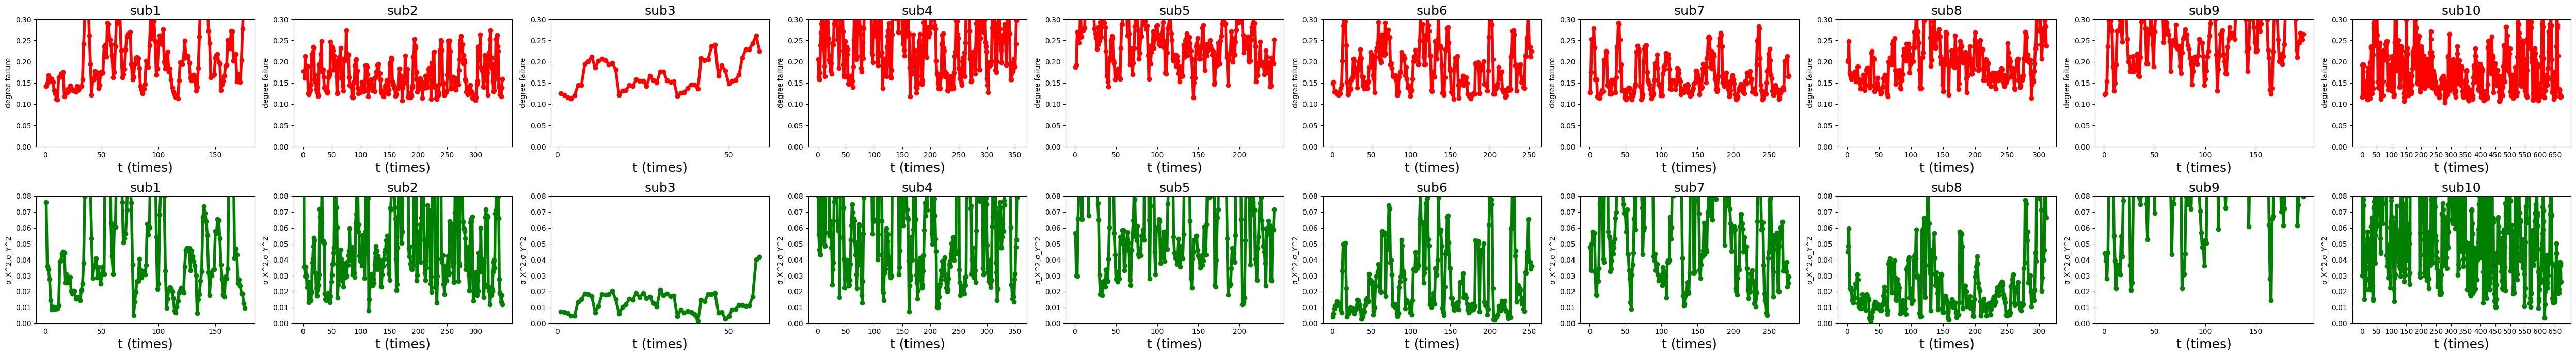

In [7]:
original_pattern = '/content/drive/MyDrive/Unity_play_data/sub1/Kendama_no1.csv'
number_people = 10
inamura_data_show = Kendama_show(original_pattern, number_people)
width = 5
df_divided = inamura_data_show.make_result("divided", width)
column = 2
inamura_data_show.show_result(df_divided, column, width)

被験者番号,推定されたα,推定されたβ,決定係数 R^2
1,1.0100000000,1.0084972768,-0.3848247148
2,1.0100000000,1.0048309818,-0.4592381286
3,1.0100000000,1.0000000000,-0.0066856831
4,1.0100000000,1.0058988096,-0.4955106950
5,1.0100000000,1.0082457063,-0.7247779213
6,1.0100000000,1.0037479881,-0.0371163403
7,1.0100000000,1.0066741100,-0.5789054475
8,1.0100000000,1.0031303157,0.0664025464
9,1.0100000000,1.0135584974,-1.0127344914
10,1.0100000000,1.0028842702,-0.2877509831


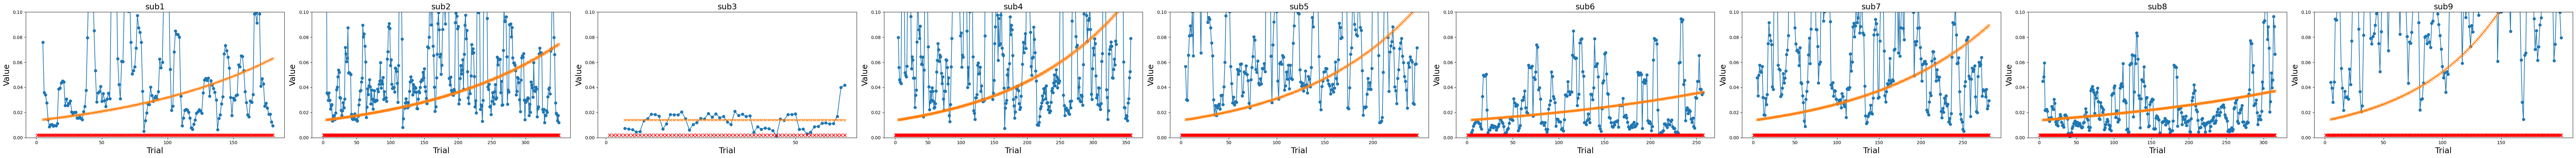

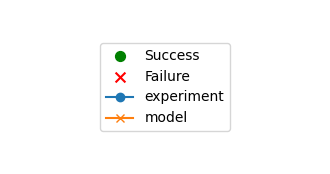

In [23]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import glob
from IPython.display import display, HTML
#おそらくデータ量が多すぎて過学習が起きていると考えられる。
#以下のコードの確認
class DataAnalysis:
    def __init__(self, original_pattern, number_people, A_dispersion_L):
        self.original_pattern = original_pattern
        self.number_people = number_people
        self.df_divided = df_divided

    # 単純移動平均(SMA)を計算する関数
    def simple_moving_average(self, values, window):
        return np.convolve(values, np.ones(window) / window, mode='valid')

    # モデルの予測関数（分散の動的変化を反映し、幅5の移動平均を使用）
    def model(self, results, alpha, beta, sigma_0):
        sigma_t2 = sigma_0
        sigmas = [sigma_t2]
        # 各試行ごとに分散を更新
        for result in results:
            if result == 1: # 成功時
                sigma_t2 = sigma_t2 / alpha
            else: # 失敗時
                sigma_t2 = sigma_t2 * beta
            sigmas.append(sigma_t2)
        # 幅5の単純移動平均を計算 (試行の分散に対して)
        sigmas = np.delete(sigmas, 0)

        sigmas_sma = self.simple_moving_average(sigmas, 5)
        return sigmas_sma # 分散の単純移動平均を返す

    # 誤差関数の定義
    def residuals(self, params, results, y_experiment, sigma_0):
        alpha, beta = params
        y_model = self.model(results, alpha, beta, sigma_0)
        return np.sum((y_experiment[:len(y_model)] - y_model) ** 2)

    # 不等式制約: x > 1 なら x - 1 > 0
    def constraint(self, x):
        return x - 1

    # パラメータ推定の関数
    def parameters_guess(self):
        person_result_list = []

        for i in range(1, self.number_people + 1):
          sigma_0 = 0.014 # 初期の分散
          # 初期推定値
          initial_guess = [1.01, 1.01]  # α と β の初期推定値
          bounds = [(1.0, None)] #1以上の制約
          constraints = {'type': 'ineq', 'fun': self.constraint}
          #推測に使用する実験データ
          df_filtered = self.df_divided[(self.df_divided['person'] == i)]
          y_experiment = abs(np.vstack(df_filtered['dispersion'].values)[:, 0] + np.vstack(df_filtered['dispersion'].values)[:, 1])

          #配列xの長さを使用して全て失敗の配列を作成
          succ_check_list = np.zeros(len(df_filtered['x'].values[0])+4)

          result = minimize(self.residuals, initial_guess, args=(succ_check_list, y_experiment, sigma_0), bounds=bounds)
          alpha, beta = result.x

          y_model_opt = self.model(succ_check_list, alpha, beta, sigma_0)
          residuals_check = abs(y_experiment - y_model_opt)
          r2 = r2_score(y_experiment, y_model_opt)

          person_result = {
              'person': i,
              'alpha': alpha,
              'beta': beta,
              'r2': r2,
              'succ_check_list': succ_check_list,
              'errors': residuals_check,
              'y_experiment': y_experiment,
              'y_model': y_model_opt
          }
          person_result_list.append(person_result)

        # 例: 新しいデータフレームに追加
        data = {
            "被験者番号": range(1, self.number_people + 1),
            "推定されたα": [person_result['alpha'] for person_result in person_result_list],
            "推定されたβ": [person_result['beta'] for person_result in person_result_list],  # βの最後の値も取得する場合
            "決定係数 R^2": [person_result['r2'] for person_result in person_result_list]         # R^2をリストにする場合
        }
        df = pd.DataFrame(data)
        pd.set_option('display.float_format', lambda x: f'{x:.10f}')
        return df, person_result_list

#ここからはまだ確認できない
class DataPlotting:
    def __init__(self, person_result_list):
      self.person_results_list = person_result_list

    # モデル・実験データのみをプロット
    def plot_results(self):
        n_cols = 9  # 1行9列のグラフ
        fig, axes = plt.subplots(1, n_cols, figsize=(80, 5))  # 1行に変更

        for i in range(n_cols):
            ax = axes[i]
            person_result = self.person_results_list[i]

            # Success/Failureの散布図
            success_check = person_result['succ_check_list']
            trials = np.arange(1, len(success_check) + 1)
            ax.scatter(trials[success_check == 1], np.ones(np.sum(success_check == 1)) * 0.1 - 0.002,
                      label='Success', marker='o', color='g', s=50, zorder=5)
            ax.scatter(trials[success_check == 0], np.ones(np.sum(success_check == 0)) * 0 + 0.002,
                      label='Failure', marker='x', color='r', s=50, zorder=5)

            # 実験データとモデルデータのプロット
            x_values = np.arange(5, len(person_result['y_experiment']) + 5)
            ax.plot(x_values, person_result['y_experiment'], label='experiment', marker='o', zorder=1)
            ax.plot(x_values, person_result['y_model'], label='model', marker='x', zorder=2)

            # グラフの基本設定
            ax.set_title(f"sub{i + 1}", fontsize=18)
            ax.set_xlabel('Trial', fontsize=18)
            ax.set_ylabel('Value', fontsize=18)
            ax.set_xticks(list(range(0, len(person_result['y_experiment']), 50)))
            ax.set_ylim(0, 0.1)

        plt.tight_layout()
        # plt.savefig(f"data_fitting_model.pdf")
        # files.download(f'data_fitting_model.pdf')
        plt.show()

        # 凡例のみを別の図で描画して保存
        fig_legend, ax_legend = plt.subplots(figsize=(4, 2))  # 新しい Figure と Axes を作成
        handles, labels = ax.get_legend_handles_labels()  # 凡例のハンドルとラベルを取得
        ax_legend.legend(handles, labels, loc='center')  # 新しい Axes に凡例を追加
        ax_legend.axis('off')  # 軸を非表示にする
        # fig_legend.savefig(f'legend.pdf', bbox_inches='tight')  # 凡例を画像として保存
        # files.download(f'legend.pdf')
        plt.show()


# 使用例
original_pattern = '/content/drive/MyDrive/Unity_play_data/sub1/Kendama_no1.csv'
number_people = 10
data_analysis = DataAnalysis(original_pattern, number_people, df_divided)
df, person_result_list = data_analysis.parameters_guess()

# データフレームをHTMLテーブルとして表示（インデックスを表示しない）
display(HTML(df.to_html(index=False)))

data_plotting = DataPlotting(person_result_list)
data_plotting.plot_results()


In [ ]:
print(df_analyze['x'][0])

[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.
  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.
  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.
  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.
  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.
  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125. 126.
 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139. 140.
 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153. 154.
 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167. 168.
 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179. 180.]
